In [3]:
!pip install --upgrade 

  Attempting uninstall: numexpr
    Found existing installation: numexpr 2.10.1
    Uninstalling numexpr-2.10.1:
      Successfully uninstalled numexpr-2.10.1


In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.tsa.api as smt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

In [8]:
data = pd.read_csv(r'C:\Users\sneha\anaconda_projects\Forecasting\AirPassengers.csv')

In [10]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Month        144 non-null    str  
 1   #Passengers  144 non-null    int64
dtypes: int64(1), str(1)
memory usage: 3.4 KB


In [11]:
data.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [12]:
data.columns = ['month_year','passengers']

In [13]:
data.head()

,month_year,passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [18]:
data['month_year'] = pd.to_datetime(data['month_year'], format='%Y-%m')

In [19]:
data.head()

,month_year,passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [20]:
data.set_index(data['month_year'],inplace=True)

In [21]:
data.head()

,month_year,passengers
month_year,,
1949-01-01,1949-01-01,112
1949-02-01,1949-02-01,118
1949-03-01,1949-03-01,132
1949-04-01,1949-04-01,129
1949-05-01,1949-05-01,121


In [22]:
data['month'] = data['month_year'].dt.month
data['year'] = data['month_year'].dt.year

In [23]:
data.head()

,month_year,passengers,month,year
month_year,,,,
1949-01-01,1949-01-01,112,1,1949
1949-02-01,1949-02-01,118,2,1949
1949-03-01,1949-03-01,132,3,1949
1949-04-01,1949-04-01,129,4,1949
1949-05-01,1949-05-01,121,5,1949


<Axes: xlabel='year'>

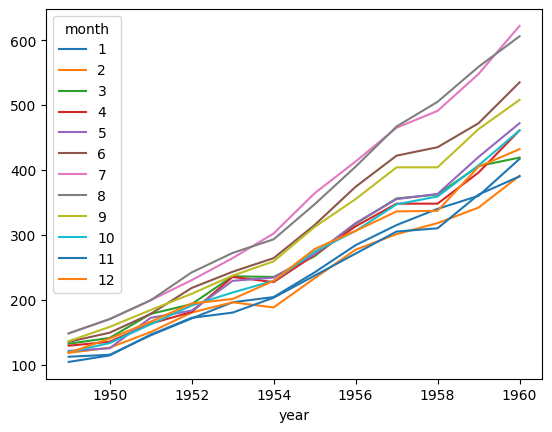

In [25]:
data.pivot(index='year',columns='month',values='passengers').plot()

<Axes: xlabel='month'>

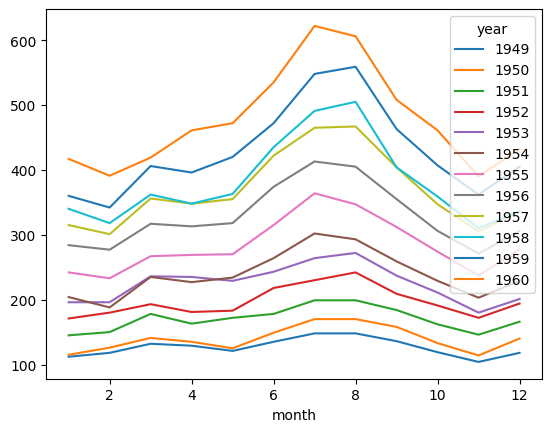

In [26]:
data.pivot(index='month',columns='year',values='passengers').plot()

<Axes: xlabel='month_year'>

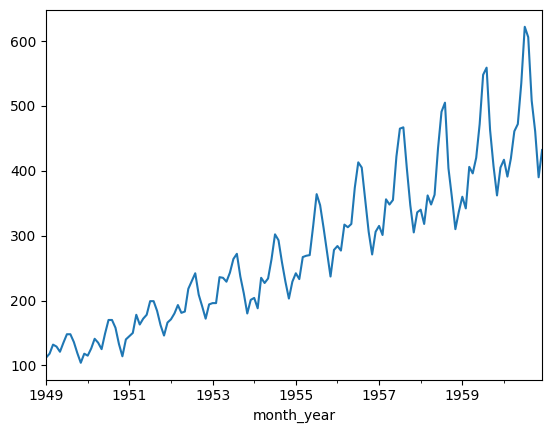

In [27]:
data['passengers'].plot()

In [28]:
ts = data['passengers']

In [30]:
deco = seasonal_decompose(ts, model='additive')

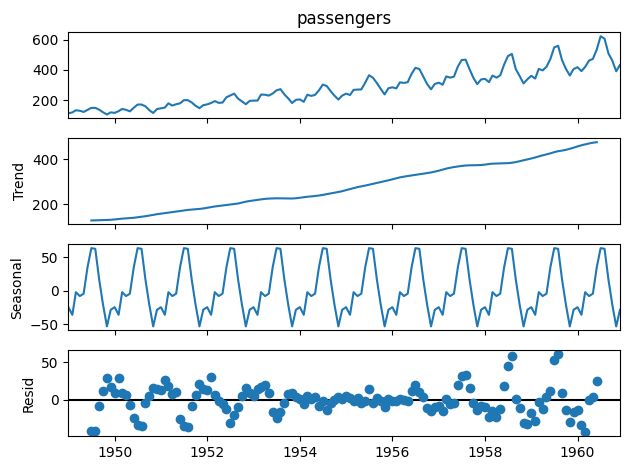

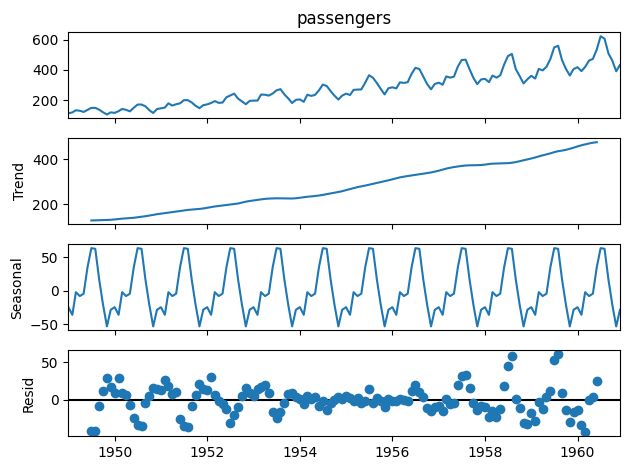

In [32]:
deco.plot()

In [34]:
pd.concat((deco.observed,deco.trend,deco.seasonal,deco.resid),axis=1).head(12)

,passengers,trend,seasonal,resid
month_year,,,,
1949-01-01,112.0,NaN,-24.748737,NaN
1949-02-01,118.0,NaN,-36.188131,NaN
1949-03-01,132.0,NaN,-2.241162,NaN
1949-04-01,129.0,NaN,-8.036616,NaN
1949-05-01,121.0,NaN,-4.506313,NaN
1949-06-01,135.0,NaN,35.402778,NaN
1949-07-01,148.0,126.791667,63.830808,-42.622475
1949-08-01,148.0,127.250000,62.823232,-42.073232
1949-09-01,136.0,127.958333,16.520202,-8.478535


In [35]:
ExponentialSmoothing?

Init signature:
ExponentialSmoothing(
    endog,
    trend=None,
    damped_trend=False,
    seasonal=None,
    *,
    seasonal_periods=None,
    initialization_method='estimated',
    initial_level=None,
    initial_trend=None,
    initial_seasonal=None,
    use_boxcox=False,
    bounds=None,
    dates=None,
    freq=None,
    missing='none',
)
Docstring:     
Holt Winter's Exponential Smoothing

Parameters
----------
endog : array_like
    The time series to model.
trend : {"add", "mul", "additive", "multiplicative", None}, optional
    Type of trend component.
damped_trend : bool, optional
    Should the trend component be damped.
seasonal : {"add", "mul", "additive", "multiplicative", None}, optional
    Type of seasonal component.
seasonal_periods : int, optional
    The number of periods in a complete seasonal cycle, e.g., 4 for
    quarterly data or 7 for daily data with a weekly cycle.
initialization_method : str, optional
    Method for initialize the recursions. One of:

    

In [84]:
def exp(timeseries, val_split_data, alpha=None, beta=None, gamma=None, trend=None, seasonal=None,
       seasonal_periods=None, verbose=False):

    best_para = []
    actual = timeseries[val_split_data:]

    for a in alpha:
        for b in beta:
            for g in gamma:

                model = ExponentialSmoothing(timeseries, trend=None, seasonal=seasonal, seasonal_periods=seasonal_periods)
                model.fit(smoothing_level=a, smoothing_trend=b, smoothing_seasonal=g)
                f_cast = model.predict(model.params, start=actual.index[0])
                score = np.where(np.float64(root_mean_squared_error(actual,f_cast)/actual).mean()>0,np.float64(mean_absolute_error(actual,f_cast)/actual).mean(),0)

                best_para.append({'alpha':a, 'beta':b, 'gamma':g, 'mae':score})

    return min(best_para, key = lambda x: x['mae'])

In [85]:
data['month_year'].sort_values(ascending=True)

month_year
1949-01-01   1949-01-01
1949-02-01   1949-02-01
1949-03-01   1949-03-01
1949-04-01   1949-04-01
1949-05-01   1949-05-01
                ...    
1960-08-01   1960-08-01
1960-09-01   1960-09-01
1960-10-01   1960-10-01
1960-11-01   1960-11-01
1960-12-01   1960-12-01
Name: month_year, Length: 144, dtype: datetime64[us]

In [86]:
alpha = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
beta = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
gamma =[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]

In [87]:
import warnings
warnings.filterwarnings('ignore')

In [88]:
exp(timeseries=ts, val_split_data='1960-01-01',alpha=alpha,beta=beta,gamma=gamma,seasonal='mul',
   trend='mul',seasonal_periods=12)

{'alpha': 0.5, 'beta': 0.1, 'gamma': 0.4, 'mae': array(0.02616396)}

In [43]:
model = ExponentialSmoothing(ts, trend='mul', seasonal='mul', seasonal_periods=12)

In [44]:
model.fit(smoothing_level=0.5, smoothing_trend=0.1, smoothing_seasonal=0.4)

In [45]:
actual = ts['1960-01-01':]

In [46]:
model.predict(start=actual.index[0], params=model.params, end='1970-01-01')

array([ 425.01385809,  400.30782071,  465.72548112,  432.00521558,
        469.63235105,  544.94278377,  614.61847079,  616.99476674,
        500.53010255,  442.05510677,  397.51074985,  437.52253161,
        451.71139034,  427.67806888,  487.11099328,  510.7904257 ,
        524.44704248,  601.43843252,  693.63512417,  684.22753947,
        568.19397663,  503.91362976,  432.17483067,  483.56403472,
        502.41684258,  475.68573563,  541.79011746,  568.12761066,
        583.31720832,  668.95102655,  771.49697006,  761.0333663 ,
        631.97481803,  560.47888145,  480.68726738,  537.84500613,
        558.8140771 ,  529.08235317,  602.60707605,  631.90100235,
        648.79566089,  744.04203611,  858.09895444,  846.4607915 ,
        702.9151787 ,  623.39368892,  534.64531626,  598.21911857,
        621.54200716,  588.47284135,  670.25085252,  702.83307708,
        721.62419278,  827.56215256,  954.42217427,  941.47760567,
        781.81872815,  693.37080173,  594.6602575 ,  665.37033

In [47]:
pd.Series(model.predict(start=actual.index[0], params=model.params, end='1970-01-01'))

0       425.013858
1       400.307821
2       465.725481
3       432.005216
4       469.632351
          ...     
116    1330.827632
117    1180.269785
118    1012.242703
119    1132.606831
120    1176.764001
Length: 121, dtype: float64

In [48]:
adfuller(ts)

(np.float64(0.8153688792060482),
 np.float64(0.991880243437641),
 13,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(996.692930839019))

In [51]:
adfuller(np.log(ts).diff(2).dropna())

(np.float64(-3.167907375288738),
 np.float64(0.021919114564039218),
 11,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(-431.93712963284486))

In [52]:
adfuller(np.log(ts))

(np.float64(-1.7170170891069607),
 np.float64(0.42236677477039125),
 13,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(-445.3990312497209))

In [53]:
ln_ts_diff2 = np.log(ts).diff(2).dropna()
ln_ts = np.log(ts)

In [61]:
train = ln_ts[:'1959-12-01']
test = ln_ts['1960-01-01':]

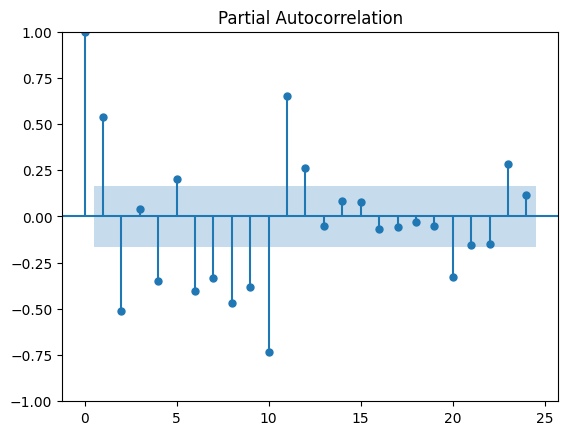

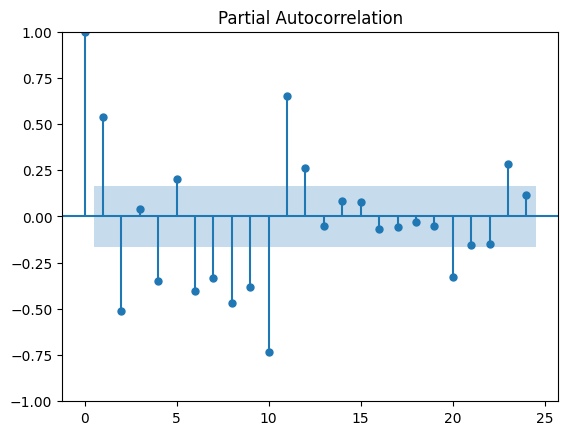

In [62]:
smt.graphics.plot_pacf(ln_ts_diff2, method='ols', lags=24)

In [63]:
sm.tsa.statespace.SARIMAX?

Init signature:
sm.tsa.statespace.SARIMAX(
    endog,
    exog=None,
    order=(1, 0, 0),
    seasonal_order=(0, 0, 0, 0),
    trend=None,
    measurement_error=False,
    time_varying_regression=False,
    mle_regression=True,
    simple_differencing=False,
    enforce_stationarity=True,
    enforce_invertibility=True,
    hamilton_representation=False,
    concentrate_scale=False,
    trend_offset=1,
    use_exact_diffuse=False,
    dates=None,
    freq=None,
    missing='none',
    validate_specification=True,
    **kwargs,
)
Docstring:     
Seasonal AutoRegressive Integrated Moving Average with eXogenous regressors
model

Parameters
----------
endog : array_like
    The observed time-series process :math:`y`
exog : array_like, optional
    Array of exogenous regressors, shaped nobs x k.
order : iterable or iterable of iterables, optional
    The (p,d,q) order of the model for the number of AR parameters,
    differences, and MA parameters. `d` must be an integer
    indicating the 

In [64]:
arima = sm.tsa.statespace.SARIMAX(endog=train, order=(1,2,1), enforce_invertibility=False, enforce_stationarity=False).fit()

In [67]:
f_cast_arima = np.exp(arima.forecast(12))

In [68]:
f_cast_arima

1960-01-01    417.072423
1960-02-01    422.701613
1960-03-01    427.090972
1960-04-01    431.270237
1960-05-01    435.440674
1960-06-01    439.641767
1960-07-01    443.881510
1960-08-01    448.161775
1960-09-01    452.483241
1960-10-01    456.846365
1960-11-01    461.251557
1960-12-01    465.699227
Freq: MS, Name: predicted_mean, dtype: float64

In [69]:
sarima = sm.tsa.statespace.SARIMAX(endog=train, order=(1,2,1), seasonal_order=(1,0,1,12), enforce_invertibility=False, enforce_stationarity=False).fit()

In [71]:
f_cast_sarima = sarima.forecast(12)

In [72]:
f_cast_sarima

1960-01-01    6.042314
1960-02-01    5.992649
1960-03-01    6.151786
1960-04-01    6.124907
1960-05-01    6.165568
1960-06-01    6.313463
1960-07-01    6.443966
1960-08-01    6.456383
1960-09-01    6.274552
1960-10-01    6.141363
1960-11-01    6.010397
1960-12-01    6.119031
Freq: MS, Name: predicted_mean, dtype: float64

In [74]:
import itertools


def sarimax(timeseries, regressor=None, p=range(0,2), d=range(0,2), q=range(0,2), P=range(0,2), D=range(0,2),
           Q=range(0,2)):

    pdq = list(itertools.product(p,d,q))
    pdq_seasonal = [(x[0],x[1],x[2],12) for x in list(itertools.product(P,D,Q))]

    best_aic = np.inf
    best_pdq = None
    best_seasonal_pdq = None
    best_score = None

    for para in pdq:
        for seasonal_para in pdq_seasonal:
            try:
                model = sm.tsa.statespace.SARIMAX(endog=timeseries, exog=regressor, order=para,
                                                 seasonal_order=seasonal_para, enforce_invertibility=False,
                                                 enforce_stationarity=False)
                result = model.fit()

                print('SARIMAX{}x{}12 - AIC:{}'.format(para,seasonal_para,result.aic))

                if result.aic<best_aic:
                    best_aic=result.aic
                    best_pdq = para
                    best_seasonal_pdq = seasonal_para
                    best_score = result

            except:
                continue

    print('SARIMAX{}x{}12 - AIC:{}'.format(best_pdq,best_seasonal_pdq,best_aic))
    print(best_score.summary().tables[0])
    print(best_score.summary().tables[1])

In [76]:
sarimax(timeseries=train)

SARIMAX(0, 0, 0)x(0, 0, 0, 12)12 - AIC:820.7741281722358
SARIMAX(0, 0, 0)x(0, 0, 1, 12)12 - AIC:624.675359250729
SARIMAX(0, 0, 0)x(0, 1, 0, 12)12 - AIC:-132.88316978763726
SARIMAX(0, 0, 0)x(0, 1, 1, 12)12 - AIC:-153.68052750954323
SARIMAX(0, 0, 0)x(1, 0, 0, 12)12 - AIC:-306.55540984734955
SARIMAX(0, 0, 0)x(1, 0, 1, 12)12 - AIC:-304.90104427888673
SARIMAX(0, 0, 0)x(1, 1, 0, 12)12 - AIC:-195.54094678118284
SARIMAX(0, 0, 0)x(1, 1, 1, 12)12 - AIC:-262.2108812665816
SARIMAX(0, 0, 1)x(0, 0, 0, 12)12 - AIC:642.5457824036158
SARIMAX(0, 0, 1)x(0, 0, 1, 12)12 - AIC:462.93123487908656
SARIMAX(0, 0, 1)x(0, 1, 0, 12)12 - AIC:-228.02351976715337
SARIMAX(0, 0, 1)x(0, 1, 1, 12)12 - AIC:-218.15624728520442
SARIMAX(0, 0, 1)x(1, 0, 0, 12)12 - AIC:-357.109069715235
SARIMAX(0, 0, 1)x(1, 0, 1, 12)12 - AIC:-357.56598712224803
SARIMAX(0, 0, 1)x(1, 1, 0, 12)12 - AIC:-238.2009382837175
SARIMAX(0, 0, 1)x(1, 1, 1, 12)12 - AIC:-299.33673087713987
SARIMAX(0, 1, 0)x(0, 0, 0, 12)12 - AIC:-210.46889658144136
SARIMAX(0

In [77]:
best_arima = sm.tsa.statespace.SARIMAX(endog=train, order=(1,0,1), enforce_invertibility=False, 
                                       enforce_stationarity=False).fit()

In [78]:
best_arima_f_cast = np.exp(best_arima.forecast(12))

In [79]:
best_arima_f_cast

1960-01-01    422.491734
1960-02-01    426.298082
1960-03-01    430.144446
1960-04-01    434.031297
1960-05-01    437.959115
1960-06-01    441.928384
1960-07-01    445.939595
1960-08-01    449.993246
1960-09-01    454.089841
1960-10-01    458.229889
1960-11-01    462.413910
1960-12-01    466.642425
Freq: MS, Name: predicted_mean, dtype: float64

In [80]:
best_sarima = sm.tsa.statespace.SARIMAX(train, order=(1,0,1), seasonal_order=(1,0,1,12), 
                                       enforce_invertibility=False, enforce_stationarity=False).fit()

In [81]:
best_sarima_f_cast = np.exp(best_sarima.forecast(12))

In [82]:
best_sarima_f_cast

1960-01-01    421.693653
1960-02-01    401.194770
1960-03-01    473.604612
1960-04-01    461.301663
1960-05-01    481.311083
1960-06-01    561.528616
1960-07-01    642.861409
1960-08-01    651.512699
1960-09-01    541.242979
1960-10-01    472.111766
1960-11-01    412.699312
1960-12-01    462.237302
Freq: MS, Name: predicted_mean, dtype: float64